In [1]:
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
# 0 - Manzana
# 1 - Naranja

# features = [[140, "Smooth"], []]

features = [[140, 1], [130, 1], [150, 0], [170, 0]]
labels = [0, 0, 1, 1]

In [3]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(features, labels)

In [4]:
print(clf.predict([[140, 0]]))

[0]


In [5]:
# Features: [weight, texture, color ] --> texture: 1 = smooth, 0 = bumpy; color: 1 = red, 2 = orange, 3 = green.
features = [
    [140, 1, 3], [130, 1, 1], [150, 0, 3], [170, 0, 2], [120, 1, 1],
    [160, 0, 2], [135, 1, 1], [155, 0, 2], [145, 1, 3], [165, 0, 2], 
    [125, 1, 3], [175, 0, 2], [115, 1, 3], [180, 0, 2], [138, 1, 3],
    [158, 0, 2], [148, 1, 1], [168, 0, 2], [132, 1, 3], [152, 0, 0]
]

# Labels: 0 = apple (smooth), 1 = orange (bumpy)
labels = [
    0, 0, 1, 1, 0,
    1, 0, 1, 0, 1, 
    0, 1, 0, 1, 0, 
    1, 0, 1, 0, 1
]

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.3, random_state = 42)

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Prediction: ", y_pred)
print("Actual: ", y_test)

Prediction:  [0 1 1 0 0 1]
Actual:  [0, 1, 1, 0, 0, 1]


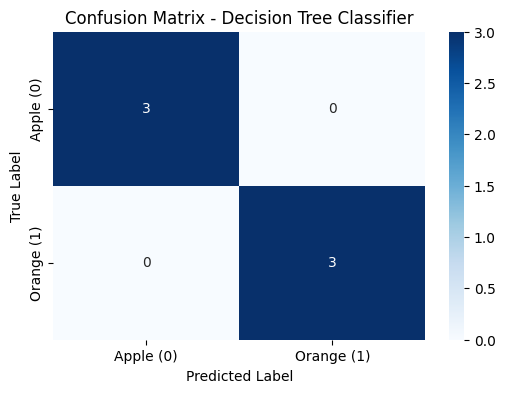

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt="d", cmap = "Blues", xticklabels = ["Apple (0)", "Orange (1)"], yticklabels = ["Apple (0)", "Orange (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree Classifier") 
plt.show()

In [22]:
df = pd.read_csv("https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv")

In [23]:
display(df.head())

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [24]:
labels = df.loc[:, "variety"]
labels = labels.map({'Setosa': 0, 'Versicolor': 1, 'Virginica': 2}).tolist()
df = df.iloc[:, 0:3]
df

,sepal.length,sepal.width,petal.length
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4
...,...,...,...
145,6.7,3.0,5.2
146,6.3,2.5,5.0
147,6.5,3.0,5.2
148,6.2,3.4,5.4


In [26]:
X_train, X_test, y_train, y_test = train_test_split(df, labels, test_size = 0.3, random_state = 42)
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Prediction: ", y_pred.tolist())
print("Actual:\n", y_test)

Prediction:  [1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0]
Actual:
 [1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0]
